In [68]:
import numpy as np
import pandas as pd
import markdown
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))
from src.models.train_model import load_data, split_data, develop_model
from src.models.predict_model import predict, evaluate_model,get_feature_importance,get_threshold_r2
from src.visualization.visualize import plot_score_comparison_chart

sys.path.append('..')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Load Preprocessed Data


In [73]:
df = load_data()
df.head(3)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,...,nsm_sin,nsm_cos,is_weekend,nsm_sin_loadtype,nsm_cos_loadtype,total_reactive,reactive_mode,pf_loss,electrical_load,near_unity_pf
0,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00,...,0.065403,0.997859,0,0.065403,0.997859,2.95,lagging_dominant,26.79,79.0305,1
1,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00,...,0.130526,0.991445,0,0.130526,0.991445,4.46,lagging_dominant,33.23,148.2058,1
2,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00,...,0.195090,0.980785,0,0.195090,0.980785,3.28,lagging_dominant,29.72,97.4816,1


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 24 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Usage_kWh                                    35040 non-null  float64       
 1   Lagging_Current_Reactive.Power_kVarh         35040 non-null  float64       
 2   Leading_Current_Reactive_Power_kVarh         35040 non-null  float64       
 3   Lagging_Current_Power_Factor                 35040 non-null  float64       
 4   Leading_Current_Power_Factor                 35040 non-null  float64       
 5   NSM                                          35040 non-null  int64         
 6   WeekStatus                                   35040 non-null  str           
 7   Day_of_week                                  35040 non-null  str           
 8   Load_Type                                    35040 non-null  str           
 9   consum

# 2. Model Development

## 2.1 Check for time gaps
There must be no gap in the timeline, row N-1 must be exactly 15 minutes befor row N.

In [75]:
target = 'Usage_kWh'

# sort by time
df = df.sort_values('consumed_date').reset_index(drop=True)

# check for gaps
time_diff = df['consumed_date'].diff()
expected_time_freq = pd.Timedelta(minutes=15)
gaps = time_diff[time_diff != expected_time_freq].dropna()
print(f"Numbers of gaps: {len(gaps)}")

# build gaps and build lag features
df['usage_lag_1'] = df['Usage_kWh'].shift(1)      # previous 15-min reading
df['usage_lag_4'] = df['Usage_kWh'].shift(4)       # 1 hour ago
df['usage_rolling_mean_4'] = df['Usage_kWh'].shift(1).rolling(4).mean()
df['usage_rolling_std_4'] = df['Usage_kWh'].shift(1).rolling(4).std()


Numbers of gaps: 0


In [76]:
df.head(5)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,...,nsm_cos_loadtype,total_reactive,reactive_mode,pf_loss,electrical_load,near_unity_pf,usage_lag_1,usage_lag_4,usage_rolling_mean_4,usage_rolling_std_4
0,3.42,3.46,0.0,70.30,100.0,0,Weekday,Monday,Light_Load,2018-01-01 00:00:00,...,1.000000,3.46,lagging_dominant,29.70,102.7620,1,NaN,NaN,NaN,NaN
1,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00,...,0.997859,2.95,lagging_dominant,26.79,79.0305,1,3.42,NaN,NaN,NaN
2,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00,...,0.991445,4.46,lagging_dominant,33.23,148.2058,1,3.17,NaN,NaN,NaN
3,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00,...,0.980785,3.28,lagging_dominant,29.72,97.4816,1,4.00,NaN,NaN,NaN
4,3.31,3.56,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,2018-01-01 01:00:00,...,0.965926,3.56,lagging_dominant,31.91,113.5996,1,3.24,3.42,3.4575,0.376685


As we expected, `usage_rolling_mean_4` needs 4 prior readings to compute an average, there simply is no ' 1 hour before '  there's no data before the start of this dataset.
`usage_lag_1` will have exactly 1 NaN (row 0 only). 
I decided to drop these 4 rows, given dataset is 35,040 rows total, losing 4 rows is completely negligible (0.01%). 

In [77]:
df = df.dropna(subset=['usage_lag_1', 'usage_lag_4', 'usage_rolling_mean_4', 'usage_rolling_std_4']).reset_index(drop=True)
df.head(5)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,...,nsm_cos_loadtype,total_reactive,reactive_mode,pf_loss,electrical_load,near_unity_pf,usage_lag_1,usage_lag_4,usage_rolling_mean_4,usage_rolling_std_4
0,3.31,3.56,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,2018-01-01 01:00:00,...,0.965926,3.56,lagging_dominant,31.91,113.5996,1,3.24,3.42,3.4575,0.376685
1,3.82,4.50,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,2018-01-01 01:15:00,...,0.946930,4.50,lagging_dominant,35.28,158.7600,1,3.31,3.17,3.4300,0.384274
2,3.28,3.56,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load,2018-01-01 01:30:00,...,0.923880,3.56,lagging_dominant,32.24,114.7744,1,3.82,4.00,3.5925,0.375000
3,3.60,4.14,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load,2018-01-01 01:45:00,...,0.896873,4.14,lagging_dominant,34.38,142.3332,1,3.28,3.24,3.4125,0.273176
4,3.60,4.28,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load,2018-01-01 02:00:00,...,0.866025,4.28,lagging_dominant,35.63,152.4964,1,3.60,3.31,3.5025,0.256174


## 2.2 Select Forecast-safe features

I exclude physical-leak features which are same-window electrical readings `Lagging_Current_Reactive.Power_kVarh_logged`, `Leading_Current_Reactive_Power_kVarh_logged`, `pf_loss`, `total_reactive`.

In [78]:
# all features = original + new
# features = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
#        'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor',
#        'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week',
#        'Load_Type', 'consumed_date',
#        'Lagging_Current_Reactive.Power_kVarh_logged',
#        'Leading_Current_Reactive_Power_kVarh_logged', 'nsm_sin', 'nsm_cos',
#        'is_weekend', 'nsm_sin_loadtype', 'nsm_cos_loadtype', 'total_reactive',
#        'reactive_mode', 'pf_loss', 'electrical_load', 'near_unity_pf']

# forecast-safe features
features = ['nsm_sin', 'nsm_cos','nsm_sin_loadtype', 'nsm_cos_loadtype', 'is_weekend','electrical_load','usage_lag_1', 'usage_lag_4', 'usage_rolling_mean_4', 'usage_rolling_std_4']

num_cols = df[features].select_dtypes(include='number').columns.tolist()
cat_cols = df[features].select_dtypes(include=['str', 'category']).columns.tolist()

num_feature = [col for col in num_cols if col != target]
cat_feature = [col for col in cat_cols if col != target]

selected_features = num_feature + cat_feature



## 2.3 Split data to define test set

I decided to split by time(column - `consumed_date`) instead of randomly.
Test set will be the  most recent 'test size' fraction of the data so it represents genuiely unseen future period rather than time-adjacent neighbors of training data row.


In [79]:
# Split data
split_by_col = 'consumed_date'
test_size = 0.3

df_train, df_test = split_data(df,split_by_col,test_size)
print(f"Size of training dataset: {df_train.shape[0]} rows")
print(f"Size of test dataset: {df_test.shape[0]} rows")

X_train, y_train = df_train[selected_features], df_train[target]
X_test, y_test  = df_test[selected_features], df_test[target]


Size of training dataset: 24525 rows
Size of test dataset: 10511 rows


## 2.4 Base Model - Linear Regression
### 2.4.1 Model Training

In [80]:
# train model
model_base = LinearRegression()
param_grid = {
            'regressor__fit_intercept': [True,False]
        }
pipeline_linear, best_params, best_cv_score_linear = develop_model(model_base, param_grid,num_feature, cat_feature, X_train, y_train)


<class 'sklearn.linear_model._base.LinearRegression'>
Best parameters found: {'regressor__fit_intercept': True}
Best score: 0.856


### 2.4.2 Model Predicttion

In [81]:
# predict
if pipeline_linear is not None:
    y_pred_linear = predict(pipeline_linear,X_test)
    print(y_pred_linear)
else:
    print(f"Unable to get base model.")

[47.77727208 16.15118074 11.06002833 ...  4.21018918  2.89684656
  2.50164267]


### 2.4.3 Model Evaluation

In [82]:
# evaluate model
if y_pred_linear is not None:
    result_linear = evaluate_model(y_test, y_pred_linear)
    print(np.isclose(result_linear['rmse'], np.sqrt(result_linear['mse'])))  # True
else:
    print(f"Unable to get predicted result.")

R² Score: 0.8854
Mean Squared Error: 109.492
Root Mean Squared Error: 10.4638
Mean Absolute Error:6.2683
True


## 2.5 Compare Model - Random Forest Regressor
### 2.5.1 Model Training


In [83]:
# train model
model_rdf = RandomForestRegressor()
param_grid = {
            'regressor__n_estimators': [50],
            'regressor__max_depth': [ 10],
            'regressor__min_samples_split': [ 5]
        }
pipeline_rdf, best_params, best_cv_score_rdf = develop_model(model_rdf,param_grid,num_feature, cat_feature, X_train, y_train)


<class 'sklearn.ensemble._forest.RandomForestRegressor'>
Best parameters found: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 50}
Best score: 0.916


### 2.5.2 Model Prediction

In [84]:
# predict
if pipeline_rdf is not None:
    y_pred_rdf = predict(pipeline_rdf,X_test)
    print(y_pred_rdf)
else:
    print(f"Unable to get model.")

[5.78295027 6.27999217 4.68877755 ... 3.72478276 3.69033397 3.69033397]


### 2.5.3 Model Evaluation

In [85]:
# evaluate model
if y_pred_rdf is not None:
    result_rdf = evaluate_model(y_test, y_pred_rdf)
    print(np.isclose(result_rdf['rmse'], np.sqrt(result_rdf['mse'])))  # True
else:
    print(f"Unable to get predicted result.")

R² Score: 0.9269
Mean Squared Error: 69.7876
Root Mean Squared Error: 8.3539
Mean Absolute Error:3.9353
True


## 2.6 Compare Model 2 - XGBoost

### 2.6.1 Model Training

In [86]:
# train model
model_xgb = xgb.XGBRegressor()

param_grid = {
  'regressor__max_depth': [3, 5, 7],
  'regressor__learning_rate': [0.1, 0.01, 0.05],
  'regressor__n_estimators': [50, 100, 200]
}

pipeline_xgb, best_params, best_cv_score_xgb = develop_model(model_xgb,param_grid,num_feature, cat_feature, X_train, y_train)

<class 'xgboost.sklearn.XGBRegressor'>
Best parameters found: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 200}
Best score: 0.921


### 2.6.2 Model Prediction

In [87]:
# predict
if pipeline_xgb is not None:
    y_pred_xgb = predict(pipeline_xgb,X_test)
    print(y_pred_xgb)
else:
    print(f"Unable to get model.")

[2.732246  5.687063  4.502697  ... 3.6264741 3.6852062 3.694931 ]


### 2.6.3 Model Evaluation

In [88]:
# evaluate model
if y_pred_xgb is not None:
    result_xgb = evaluate_model(y_test, y_pred_xgb)
    print(np.isclose(result_xgb['rmse'], np.sqrt(result_xgb['mse'])))  # True
else:
    print(f"Unable to get predicted result.")

R² Score: 0.9257
Mean Squared Error: 70.9349
Root Mean Squared Error: 8.4223
Mean Absolute Error:4.0995
True


# 3. Score Comparison

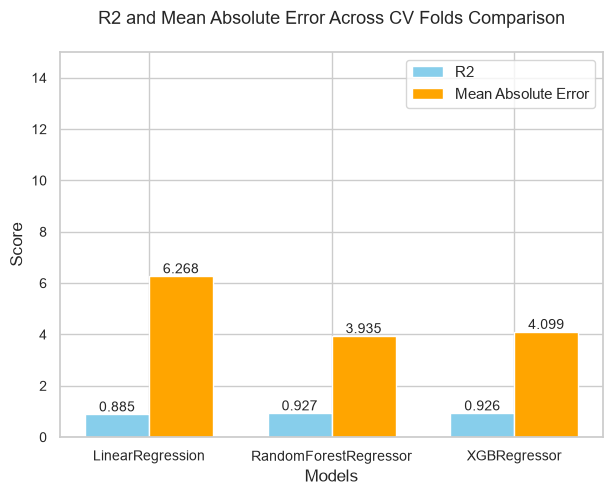

In [89]:
models = [pipeline_linear.named_steps['regressor'].__class__.__name__, pipeline_rdf.named_steps['regressor'].__class__.__name__, pipeline_xgb.named_steps['regressor'].__class__.__name__]
r2_list = [result_linear['r2'], result_rdf['r2'], result_xgb['r2']]
mae_list = [result_linear['mae'],result_rdf['mae'],result_xgb['mae']]

plot_score_comparison_chart(models,r2_list, mae_list)


# 4. Finding the feature importance
I extract features names from the preprocessing steps to get feature importance.

# 4.1 Feature Importance in Linear Regression

                feature  Importance
6           usage_lag_1   20.994583
8  usage_rolling_mean_4    8.855377
5       electrical_load    6.792854
7           usage_lag_4    4.387494
2      nsm_sin_loadtype    2.636768
3      nsm_cos_loadtype    2.310853
0               nsm_sin    0.952270
1               nsm_cos    0.798991
4            is_weekend    0.560789
9   usage_rolling_std_4    0.443220


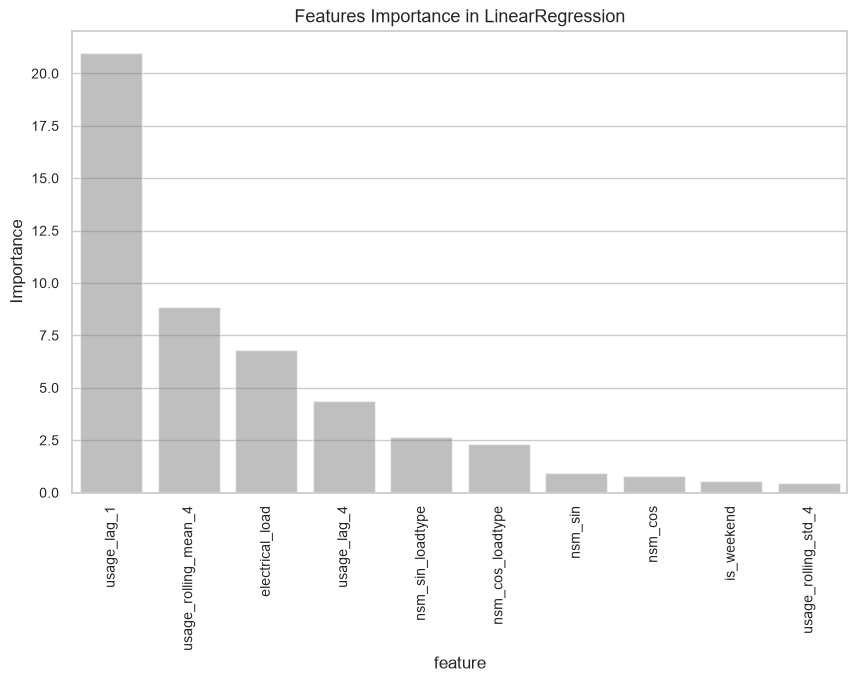

In [90]:
model_name = pipeline_linear.named_steps['regressor'].__class__.__name__
feature_importances_linear = get_feature_importance(pipeline_linear, model_name)

# 4.2 Feature Importance in Random Forest Regressor

                feature  Importance
6           usage_lag_1    0.867068
5       electrical_load    0.075540
1               nsm_cos    0.016298
8  usage_rolling_mean_4    0.013349
3      nsm_cos_loadtype    0.009722
9   usage_rolling_std_4    0.009055
7           usage_lag_4    0.004161
0               nsm_sin    0.002105
2      nsm_sin_loadtype    0.001824
4            is_weekend    0.000879


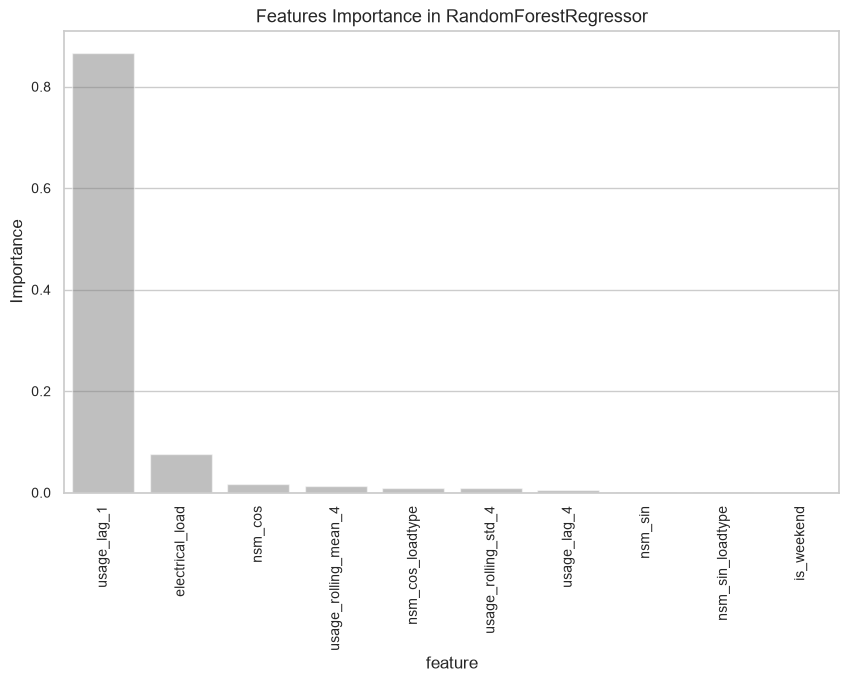

In [91]:
model_name = pipeline_rdf.named_steps['regressor'].__class__.__name__
feature_importances_rdf = get_feature_importance(pipeline_rdf, model_name)

# 4.3 Feature Importance in XGBoost Regressor

                feature  Importance
6           usage_lag_1    0.816693
5       electrical_load    0.056938
1               nsm_cos    0.037937
3      nsm_cos_loadtype    0.024956
8  usage_rolling_mean_4    0.018705
9   usage_rolling_std_4    0.011909
0               nsm_sin    0.009553
4            is_weekend    0.009372
2      nsm_sin_loadtype    0.008180
7           usage_lag_4    0.005758


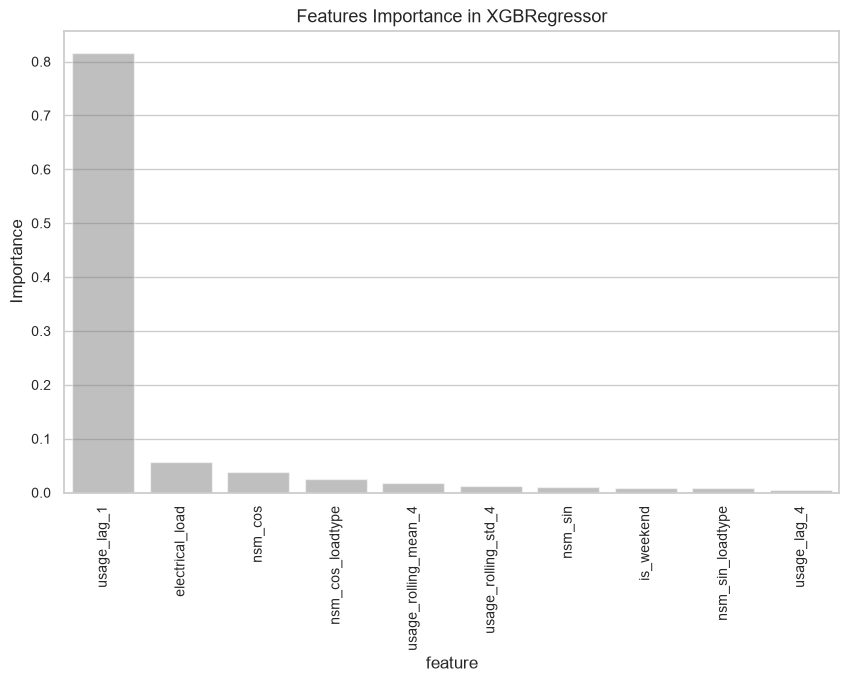

In [92]:
model_name = pipeline_xgb.named_steps['regressor'].__class__.__name__
feature_importances_xgb = get_feature_importance(pipeline_xgb, model_name)

# 4.4 Importance Features

In [93]:
top_feature_linear = pd.DataFrame({'Model': 'Linear', 'Feature':feature_importances_linear.iloc[:3]['feature'] })
top_feature_rdf = pd.DataFrame({'Model': 'RDF', 'Feature':feature_importances_rdf.iloc[:3]['feature'] })
top_feature_xgb = pd.DataFrame({'Model': 'XGB', 'Feature':feature_importances_xgb.iloc[:3]['feature'] })

all_imp_features = pd.concat([top_feature_linear, top_feature_rdf, top_feature_xgb])

print(all_imp_features.to_markdown())

|    | Model   | Feature              |
|---:|:--------|:---------------------|
|  6 | Linear  | usage_lag_1          |
|  8 | Linear  | usage_rolling_mean_4 |
|  5 | Linear  | electrical_load      |
|  6 | RDF     | usage_lag_1          |
|  5 | RDF     | electrical_load      |
|  1 | RDF     | nsm_cos              |
|  6 | XGB     | usage_lag_1          |
|  5 | XGB     | electrical_load      |
|  1 | XGB     | nsm_cos              |


# 5. Evaluation By Business Requirement

Let's assume business context and thresholds are as following; 

**Business KPI Table**
| Metric | Business Meaning | Target/Threshold
| --- | --- | --- |
| R2  | Explains usage patterns using only forecast-safe (pre-consumption) features | >= 0.75
| MAE | Average prediction error, vs naive persistence baseline | ≥ 30% improvement over baseline
| MAE by Load_Type | Consistency of error across Light/Medium/Maximum load |  No class > 1.5× overall MAE
| MAE (weekday − weekend) | Error stability across day types | < 5 kWh




## 5.1 Evaluation Metric - R2

In [94]:
r2_list

[0.8854, 0.9269, 0.9257]

In [95]:
r2_threshold = 0.75
best_r2 = get_threshold_r2(r2_list,r2_threshold)
best_r2

[0.8854, 0.9269, 0.9257]